In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##0. Datas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

In [ ]:
# ==========================
# Save Figures Automatically
# ==========================

saved_figures = {}

_original_show = plt.show


def save_and_show(*args, **kwargs):

    fig = plt.gcf()


    # Save only figures that contain real plots

    if len(fig.axes) > 0:

        name = f"Fig_{len(saved_figures)+1}"

        saved_figures[name] = fig


    # Temporarily restore original show
    # to avoid recursive saving

    plt.show = _original_show


    _original_show(*args, **kwargs)


    # Re-enable saving

    plt.show = save_and_show



plt.show = save_and_show

A binary target variable is generated by thresholding the financial risk score at 3:

In [ ]:
# Set the path

path = '/content/drive/My Drive/DtaSc26/Mid_Proj/'   # TODO: point this to your local Olist folder

datas = pd.read_csv(path + "model data.csv")

df = datas

df.describe()

features = df.columns.tolist()
print(features)
dfC = df.copy()
   # Target: 1 = at risk (score 3-7), 0 = otherwise.
dfC["AtRisk"] = (df['financial_risk_score'] >= 3).astype(int)

['YelidBrham', 'female', 'Gil', 'ShnatAliya', 'MatzavMishp', 'MispYeladim', 'Dat', 'SherutTzahal', 'SherutLeumi', 'RishyonNehiga', 'SugMeshekBait_C', 'Earners', 'health_problem', 'ShnotLimud', 'hebrew_proficiency', 'MaamadAvoda_C_wp', 'HekefMisra_C_wp', 'MerutzeAvoda_wp', 'work_income_level', 'HitnadvutShana', 'TrumaShana', 'AchrayutKesef', 'MenahelTazrim', 'MishtameshAppMaakav', 'HoraotKeva', 'HashkaotBank', 'HassachMezuman', 'HassachGmach', 'HashkaotShukHon', 'HashkaotMatbeotVirt', 'HashkaotAher', 'YedaHashkaa', 'SikunHashkaot', 'LoHosech', 'HeshbonotBazman', 'MatarotKaspiot', 'ShokelKniot', 'FinancialLiteracyScore', 'financial_risk_score']


In [ ]:
features = [
    'YelidBrham', 'female', 'Gil', 'ShnatAliya', 'MatzavMishp', 'MispYeladim',
    'Dat', 'SherutTzahal', 'SherutLeumi', 'RishyonNehiga', 'SugMeshekBait_C',
    'Earners', 'health_problem', 'ShnotLimud', 'hebrew_proficiency',
    'MaamadAvoda_C_wp', 'HekefMisra_C_wp', 'MerutzeAvoda_wp',
    'work_income_level', 'HitnadvutShana', 'TrumaShana', 'AchrayutKesef',
    'MenahelTazrim', 'MishtameshAppMaakav', 'HoraotKeva', 'HashkaotBank',
    'HassachMezuman', 'HassachGmach', 'HashkaotShukHon',
    'HashkaotMatbeotVirt', 'HashkaotAher', 'YedaHashkaa',
    'SikunHashkaot', 'LoHosech', 'HeshbonotBazman',
    'MatarotKaspiot', 'ShokelKniot'
]

In [ ]:
X = dfC[features]
y = dfC["AtRisk"]


In [ ]:
#splitting for train and test for dumber classifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

##1. Baseline Model Evaluation

This section evaluates a baseline classifier with a uniform random prediction strategy.  
Performance is measured on the independent test set using Accuracy, Recall, and F1-score.  
The results provide a reference benchmark for comparison with the trained supervised models.

In [ ]:
from sklearn.metrics import f1_score, recall_score, accuracy_score

# Dummy baseline, strategy="uniform" (random 50%-50% prediction)
# chosen to obtain non-zero F1 and Recall values
baseline = DummyClassifier(
    strategy="uniform",
    random_state=42
).fit(
    X_train,
    y_train
)

baseline_pred = baseline.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred
)

baseline_recall = recall_score(
    y_test,
    baseline_pred
)


# Create results table with one row for the Dummy Classifier

results_table = pd.DataFrame({
    "Model": ["DummyClass. ('uniform')"],
    "Accuracy": [round(baseline_accuracy, 3)],
    "F1 Score": [round(baseline_f1, 3)],
    "Recall": [round(baseline_recall, 3)]
})


# Display the table

print(results_table)

                     Model  Accuracy  F1 Score  Recall
0  DummyClass. ('uniform')     0.504     0.312   0.489


# 2. Supervised Classification Using GMM-Derived Features

## Overview

This approach combines unsupervised and supervised learning by applying a Gaussian Mixture Model (GMM) as an unsupervised feature generation step within the classification pipeline.

The GMM is used to learn the underlying data distribution without using class labels and generates additional features based on soft cluster membership probabilities. These probability-based features represent the degree of association of each observation with the learned Gaussian components and may capture hidden patterns, latent structures, and complex relationships within the data.

The GMM-derived features are not used instead of the original variables. Instead, they are concatenated with the existing features inside the Pipeline:

**Original Features + GMM-Derived Features → Classification Model**

The resulting expanded feature representation is then provided as the input to the supervised classification models, allowing them to utilize both the original characteristics of the observations and additional distribution-based information learned by the GMM.

## Modeling Approach

The combined feature space, consisting of the original features together with the GMM-derived features, is evaluated using three supervised classification algorithms:

- Logistic Regression
- Random Forest
- Gradient Boosting

The complete workflow is optimized using `GridSearchCV` with cross-validation.

The optimization process evaluates different configurations of:

- GMM parameters, including the number of components, covariance structure, and initialization settings
- Classifier hyperparameters
- Classification decision thresholds

For each classifier, models using the original feature set alone are compared with models using the augmented feature space containing both original and GMM-derived features.

The optimal configuration is selected according to the highest cross-validation F1 score.

## Data Leakage Prevention

All data-dependent operations are included inside the Pipeline:

- Missing value imputation
- Feature scaling
- GMM fitting and generation of GMM-derived features
- Model training

Each cross-validation fold learns these transformations exclusively from its training subset. The GMM is fitted only on the training portion of each fold, and the resulting GMM-derived features for validation data are generated using this fitted model.

This procedure prevents Data Leakage and ensures that validation performance reflects the expected model behavior on previously unseen data.

After selecting the best configuration, the complete pipeline is retrained on the full training dataset and evaluated on an independent test set.

In [ ]:
print(r"""
                         Training Data
                              |
                              v
                    +-------------------+
                    |   GridSearchCV    |
                    |       CV = 3      |
                    +-------------------+
                              |
                              v
                  Repeat for each CV Fold

        +-----------------------------------------+
        |              Pipeline                   |
        |                                         |
        |  Training Fold Only                     |
        |                                         |
        |  1. Missing Value Imputation            |
        |     (Median learned from Train Fold)    |
        |              |                          |
        |              v                          |
        |  2. Feature Scaling                     |
        |     (Parameters learned from Train Fold)|
        |              |                          |
        |              v                          |
        |  3. GMM Fitting                         |
        |     (Distribution learned from          |
        |      Train Fold only)                   |
        |              |                          |
        |              v                          |
        |  GMM-Derived Features                   |
        |                                         |
        +-----------------------------------------+
                              |
                              v

        +-----------------------------------------+
        |        Feature Augmentation             |
        |                                         |
        | Original Features + GMM Features        |
        |                                         |
        +-----------------------------------------+
                              |
                              v

        +-----------------------------------------+
        |     Supervised Classification           |
        |                                         |
        | Logistic Regression                     |
        | Random Forest                           |
        | Gradient Boosting                       |
        +-----------------------------------------+
                              |
                              v

                 Validation Fold Evaluation
                         (F1 Score)


        Data Leakage Prevention
---------------------------------------------------------
Imputer, Scaler, GMM and Classifier are fitted only on
the training portion of each CV fold.

Validation data and test data are only transformed using
the fitted pipeline and never influence model fitting.
---------------------------------------------------------
""")


                           RAW DATA (X, y)
                                 |
                                 v
                      +-----------------------+
                      |   Train / Test Split  |
                      +-----------------------+
                           |             |
                           |             |
                           v             v
                      X_train         X_test
                           |
                           v
                  +----------------------+
                  |     GridSearchCV     |
                  |        CV = 3        |
                  +----------------------+
                           |
                           v
                 Repeat for every CV Fold
                           |
                           v
                +-------------------------+
                |      Pipeline           |
                +-------------------------+
                | SimpleImputer (median)  |
    

In [ ]:
# ==========================
# Imports
# ==========================

import numpy as np                                      # Numerical operations

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin

from sklearn.mixture import GaussianMixture             # GMM clustering model

from sklearn.pipeline import Pipeline                  # Combine preprocessing and model steps

from sklearn.impute import SimpleImputer               # Missing values handling

from sklearn.preprocessing import StandardScaler       # Feature normalization

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, f1_score



# ==========================
# Configuration
# ==========================

RANDOM_STATE = 42                                      # Reproducibility seed

N_GMM_COMPONENTS = [2, 5, 7]                          # Number of Gaussian clusters to test

GMM_COVARIANCE_TYPES = ["full", "tied"]                        # GMM covariance structure

GMM_N_INIT = [2, 5]

GMM_WARM_START = [ True]

CLASSIFICATION_THRESHOLDS = [0.1, 0,2, 0.3, 0.4]                      # Classification decision thresholds

LR_C_VALUES = [0.01, 0.05]                                   # Logistic Regression regularization

RF_N_ESTIMATORS = [30, 60, 90]                             # Number of trees

RF_MAX_DEPTH = [5, 7]                                   # Maximum tree depth

GB_N_ESTIMATORS = [30, 60, 90]                             # Number of boosting stages

GB_LEARNING_RATE = [0.01, 0.05, 0.07]                  # Gradient boosting learning rates

GB_MAX_DEPTH = [1, 3, 7]                              # Tree depth for boosting



# ==========================
# Train/Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)                                                       # Split raw data before any learned transformation



# ==========================
# GMM Feature Generator
# ==========================

class GMMFeatureGenerator(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        n_components=10,
        covariance_type="full",
        n_init=1,
        warm_start=False,
        random_state=RANDOM_STATE
    ):

        self.n_components = n_components
        self.covariance_type = covariance_type
        self.n_init = n_init
        self.warm_start = warm_start
        self.random_state = random_state

    def fit(self, X, y=None):

        self.gmm_ = GaussianMixture(
             n_components=self.n_components,
             covariance_type=self.covariance_type,
             n_init=self.n_init,
             warm_start=self.warm_start,
             random_state=self.random_state
)                                              # Create GMM model with selected parameters

        self.gmm_.fit(X)                                # Learn Gaussian distributions from training fold only

        return self


    def transform(self, X):

        gmm_features = self.gmm_.predict_proba(X)        # Generate soft cluster probabilities as new features

        return np.hstack(
            (
                X,
                gmm_features
            )
        )                                               # Combine original features with GMM features



# ==========================
# Threshold Wrapper
# ==========================

class ThresholdClassifier(BaseEstimator, ClassifierMixin):

    def __init__(
        self,
        model=None,
        threshold=0.5
    ):
        self.model = model
        self.threshold = threshold


    def fit(self, X, y):

        self.model.fit(
            X,
            y
        )                                               # Train selected classifier

        self.classes_ = self.model.classes_             # Required sklearn classifier attribute

        return self


    def predict(self, X):

        probabilities = self.model.predict_proba(X)[:, 1] # Get probability of positive class

        return (
            probabilities >= self.threshold
        ).astype(int)                                   # Convert probabilities into class labels


    def predict_proba(self, X):

        return self.model.predict_proba(X)              # Return original model probabilities



# ==========================
# Pipeline
# ==========================

pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")                # Learn missing value replacement inside each CV fold
    ),

    (
        "scaler",
        StandardScaler()                                # Learn scaling parameters inside each CV fold
    ),

    (
        "gmm",
        GMMFeatureGenerator()                           # Create additional GMM based features
    ),

    (
        "model",
        ThresholdClassifier()                           # Train classifier using transformed features
    )

])



# ==========================
# Grid Search Parameters
# ==========================

param_grid = [

    {
        "gmm": ["passthrough"],                         # Switch OFF GMM: compare model using original features only

        "model__model": [
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        ],

        "model__model__C": LR_C_VALUES,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": [
            GMMFeatureGenerator()
        ],

        "gmm__n_components": N_GMM_COMPONENTS,

        "gmm__covariance_type": GMM_COVARIANCE_TYPES,

        "gmm__n_init": GMM_N_INIT,

        "gmm__warm_start": GMM_WARM_START,

        "model__model": [
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        ],

        "model__model__C": LR_C_VALUES,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": ["passthrough"],                         # Switch OFF GMM: compare model using original features only

        "model__model": [
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": RF_N_ESTIMATORS,

        "model__model__max_depth": RF_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": [
            GMMFeatureGenerator()
        ],                                              # Switch ON GMM: compare model using GMM generated features

        "gmm__n_components": N_GMM_COMPONENTS,

        "gmm__covariance_type": GMM_COVARIANCE_TYPES,

        "model__model": [
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": RF_N_ESTIMATORS,

        "model__model__max_depth": RF_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": ["passthrough"],                         # Switch OFF GMM: compare model using original features only

        "model__model": [
            GradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": GB_N_ESTIMATORS,

        "model__model__learning_rate": GB_LEARNING_RATE,

        "model__model__max_depth": GB_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": [
            GMMFeatureGenerator()
        ],                                              # Switch ON GMM: compare model using GMM generated features

        "gmm__n_components": N_GMM_COMPONENTS,

        "gmm__covariance_type": GMM_COVARIANCE_TYPES,

        "model__model": [
            GradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": GB_N_ESTIMATORS,

        "model__model__learning_rate": GB_LEARNING_RATE,

        "model__model__max_depth": GB_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    }

]
# ==========================
# GridSearchCV
# ==========================

# No Data Leakage: Pipeline fits all learned transformations only inside each CV training fold

grid = GridSearchCV(
    estimator=pipeline,                                # Optimize preprocessing + feature generation + classifier together
    param_grid=param_grid,                             # Test all selected hyperparameter combinations
    cv=3,                                              # Use three train/validation splits
    scoring="f1",                                      # Select best model according to F1 score
    n_jobs=-1,                                         # Use all available CPU cores
    refit=True                                         # Retrain best pipeline on complete X_train
)



# ==========================
# Model Training
# ==========================

grid.fit(
    X_train,
    y_train
)                                                     # Raw data enters pipeline; preprocessing happens automatically








GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('gmm', GMMFeatureGenerator()),
                                       ('model', ThresholdClassifier())]),
             n_jobs=-1,
             param_grid=[{'gmm': ['passthrough'],
                          'model__model': [LogisticRegression(max_iter=1000,
                                                              random_state=42)],
                          'model__model__C': [0.01, 0.05],
                          'model__threshold': [0.1, 0, 2...
                          'model__threshold': [0.1, 0, 2, 0.3, 0.4]},
                         {'gmm': [GMMFeatureGenerator()],
                          'gmm__covariance_type': ['full', 'tied'],
                          'gmm__n_components': [2, 5, 7],
                          'model__model': [GradientBoostingClassifier(random_state=42)],
                          'model__model__learning_rate': [0.01, 0.05, 0.07],
                          'model__model__max_depth': [1, 3, 7],
                          'model__model__n_estimators': [30, 60, 90],
                          'model__threshold': [0.1, 0, 2, 0.3, 0.4]}],
             scoring='f1')

##3. Summary of Final Model Evaluation With and Without GMM Features

This section summarizes the final evaluation results of the selected supervised models, chosen according to their highest cross-validation (CV) performance with GMM features enabled.  
Each selected model is compared against an identical configuration without GMM features, while preserving the same supervised model hyperparameters.  
The evaluation is conducted exclusively on the independent test set using Accuracy, Recall, and F1-score metrics.  
The results provide an overall assessment of the contribution of GMM-based feature generation to the final predictive performance.

In [ ]:
print(r"""
                 GRIDSEARCHCV RESULTS
                        |
                        v
             +----------------------+
             |   CV Results Table   |
             +----------------------+
                        |
                        v
          +---------------------------+
          |  For Each Classifier      |
          |---------------------------|
          | Logistic Regression       |
          | Random Forest             |
          | Gradient Boosting         |
          +---------------------------+
                        |
                        v
     Select Best GMM Configuration
                        |
                        v
             Create Two Pipelines
                        |
               +--------+--------+
               |                 |
               v                 v
         With GMM         Without GMM
     (same parameters) (same parameters)
               |                 |
               +--------+--------+
                        |
                        v
      Train on X_train & Evaluate on X_test
          (Accuracy, Recall, F1)
                        |
                        v
         Build Comparison Results Table
                        |
                        v
      Highlight Best CV & Best Test Model
""")


                 GRIDSEARCHCV RESULTS
                        |
                        v
             +----------------------+
             |   CV Results Table   |
             +----------------------+
                        |
                        v
          +---------------------------+
          |  For Each Classifier      |
          |---------------------------|
          | Logistic Regression       |
          | Random Forest             |
          | Gradient Boosting         |
          +---------------------------+
                        |
                        v
     Select Best GMM Configuration
                        |
                        v
             Create Two Pipelines
                        |
               +--------+--------+
               |                 |
               v                 v
         With GMM         Without GMM
     (same parameters) (same parameters)
               |                 |
               +--------+--------+
          

In [ ]:
# ==========================
# Best Model Results By Classifier
# ==========================

from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.base import clone
import pandas as pd
from tabulate import tabulate


# ==========================
# Convert CV Results
# ==========================

cv_results = pd.DataFrame(
    grid.cv_results_
)


best_models = []


# ==========================
# Extract Hyperparameters
# ==========================

def extract_parameters(params):

    return {
        "GMM_N": params.get("gmm__n_components", "-"),
        "Cov": params.get("gmm__covariance_type", "-"),
        "Threshold": params.get("model__threshold", "-"),
        "C": params.get("model__model__C", "-"),
        "Trees": params.get("model__model__n_estimators", "-"),
        "Depth": params.get("model__model__max_depth", "-"),
        "LR": params.get("model__model__learning_rate", "-")
    }



# ==========================
# Evaluate Each Classifier
# ==========================

for classifier_name in [
    "LogisticRegression",
    "RandomForestClassifier",
    "GradientBoostingClassifier"
]:


    classifier_results = cv_results[
        cv_results["param_model__model"]
        .apply(
            lambda x: type(x).__name__ == classifier_name
        )
    ]


    # ==========================
    # Best WITH GMM
    # ==========================

    gmm_results = classifier_results[
        classifier_results["param_gmm"]
        .apply(
            lambda x: x != "passthrough"
        )
    ]


    best_index = gmm_results[
        "mean_test_score"
    ].idxmax()


    best_parameters = cv_results.loc[
        best_index,
        "params"
    ]


    cv_f1 = cv_results.loc[
        best_index,
        "mean_test_score"
    ]


    # ==========================
    # Train WITH GMM
    # ==========================

    model_with_gmm = clone(
        pipeline
    )


    model_with_gmm.set_params(
        **best_parameters
    )


    model_with_gmm.fit(
        X_train,
        y_train
    )


    y_pred = model_with_gmm.predict(
        X_test
    )


    params_display = extract_parameters(
        best_parameters
    )


    best_models.append(
        {
            "Model": classifier_name.replace(
                "Classifier",
                ""
            ),

            "GMM": "With GMM",

            **params_display,

            "CV_F1": round(
                cv_f1,
                4
            ),

            "Accuracy": round(
                accuracy_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "Recall": round(
                recall_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "F1": round(
                f1_score(
                    y_test,
                    y_pred
                ),
                4
            )
        }
    )



    # ==========================
    # Train WITHOUT GMM
    # ==========================

    without_gmm_parameters = best_parameters.copy()


    without_gmm_parameters.pop(
        "gmm__n_components",
        None
    )


    without_gmm_parameters.pop(
        "gmm__covariance_type",
        None
    )


    model_without_gmm = clone(
        pipeline
    )


    model_without_gmm.set_params(
        **without_gmm_parameters
    )


    model_without_gmm.steps[2] = (
        "gmm",
        "passthrough"
    )


    model_without_gmm.fit(
        X_train,
        y_train
    )


    y_pred = model_without_gmm.predict(
        X_test
    )


    params_display = extract_parameters(
        best_parameters
    )


    params_display["GMM_N"] = "-"
    params_display["Cov"] = "-"


    best_models.append(
        {
            "Model": classifier_name.replace(
                "Classifier",
                ""
            ),

            "GMM": "Without GMM",

            **params_display,

            "CV_F1": "-",

            "Accuracy": round(
                accuracy_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "Recall": round(
                recall_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "F1": round(
                f1_score(
                    y_test,
                    y_pred
                ),
                4
            )
        }
    )



# ==========================
# Create Comparison Table
# ==========================

results_table = pd.DataFrame(
    best_models
)

# Order models by their WITH GMM Test F1

model_order = (
    results_table[
        results_table["GMM"] == "With GMM"
    ]
    .sort_values(
        by="F1",
        ascending=False
    )["Model"]
    .tolist()
)

results_table["Model"] = pd.Categorical(
    results_table["Model"],
    categories=model_order,
    ordered=True
)

results_table["GMM"] = pd.Categorical(
    results_table["GMM"],
    categories=[
        "With GMM",
        "Without GMM"
    ],
    ordered=True
)

results_table = results_table.sort_values(
    by=[
        "Model",
        "GMM"
    ]
).reset_index(
    drop=True
)


# ==========================
# Highlight Best Models
# ==========================

results_table_marked = results_table.astype(str).copy()


# Best model according to GridSearchCV (highest CV_F1)

cv_rows = results_table[
    results_table["CV_F1"] != "-"
]

best_cv_index = cv_rows["CV_F1"].astype(float).idxmax()


# Best model according to Test F1

best_test_index = results_table["F1"].idxmax()



# Same model wins both criteria

if best_cv_index == best_test_index:

    for column in results_table.columns:

        value = results_table_marked.loc[
            best_cv_index,
            column
        ]

        results_table_marked.loc[
            best_cv_index,
            column
        ] = (
            "***"
            + value
            + "***"
        )


# Different models win

else:

    for column in results_table.columns:

        value = results_table_marked.loc[
            best_cv_index,
            column
        ]

        results_table_marked.loc[
            best_cv_index,
            column
        ] = (
            "*"
            + value
            + "*"
        )


    for column in results_table.columns:

        value = results_table_marked.loc[
            best_test_index,
            column
        ]

        results_table_marked.loc[
            best_test_index,
            column
        ] = (
            "**"
            + value
            + "**"
        )

# ==========================
# Display Table
# ==========================


print(
    "\n"
    "For each classifier, the displayed hyperparameters were selected from the\n"
    "Cross-Validation results with GMM enabled.\n"
    "The corresponding 'Without GMM' model uses exactly the same hyperparameters,\n"
    "with only the GMM feature generation stage removed, allowing a direct\n"
    "comparison of the contribution of the GMM features.\n"
    "The CV_F1 column reports the Cross-Validation F1 score of the selected "
    "'With GMM' configuration.\nSince the 'Without GMM' models were not selected "
    "through Cross-Validation,\nno CV_F1 value is reported for those rows.\n"
    "Accuracy, Recall and F1 were computed on the independent test set after\n"
    "retraining each pipeline on the complete training data.\n"
    "* indicates the model selected by GridSearchCV according to the highest\n"
    "Cross-Validation F1 score (CV_F1).\n"
    "** indicates the model that achieved the highest Test F1 score.\n"
    "*** indicates the model that achieved both the highest Cross-Validation\n"
    "F1 score (CV_F1) and the highest Test F1 score."
)

print("\nBEST MODEL COMPARISON: WITH GMM vs WITHOUT GMM")
print("=" * 160)


print(
    tabulate(
        results_table_marked,
        headers="keys",
        tablefmt="github",
        showindex=False,
        stralign="center",
        numalign="center"
    )
)


print("=" * 160)


For each classifier, the displayed hyperparameters were selected from the
Cross-Validation results with GMM enabled.
The corresponding 'Without GMM' model uses exactly the same hyperparameters,
with only the GMM feature generation stage removed, allowing a direct
comparison of the contribution of the GMM features.
The CV_F1 column reports the Cross-Validation F1 score of the selected 'With GMM' configuration.
Since the 'Without GMM' models were not selected through Cross-Validation,
no CV_F1 value is reported for those rows.
Accuracy, Recall and F1 were computed on the independent test set after
retraining each pipeline on the complete training data.
* indicates the model selected by GridSearchCV according to the highest
Cross-Validation F1 score (CV_F1).
** indicates the model that achieved the highest Test F1 score.
*** indicates the model that achieved both the highest Cross-Validation
F1 score (CV_F1) and the highest Test F1 score.

BEST MODEL COMPARISON: WITH GMM vs WITHOUT GMM
|

##4. Final Test Evaluation

This section evaluates the best-performing model selected through cross-validation (CV) on the independent test set.  
Performance is assessed using Accuracy, F1-score, and a classification report to summarize the model's predictive performance.

In [ ]:
# ==========================
# Final Test Evaluation
# ==========================

from sklearn.metrics import accuracy_score, f1_score, classification_report


# Retrieve fully fitted best pipeline

best_model = grid.best_estimator_


# ==========================
# Selected Model Name
# ==========================

selected_model = (
    best_model
    .named_steps["model"]
    .model
)

model_name = type(selected_model).__name__


print("\nSelected Model:")
print(model_name)


# ==========================
# Test Prediction
# ==========================

y_pred = best_model.predict(
    X_test
)


# ==========================
# Evaluation Metrics
# ==========================

print("\nTest Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nTest F1:")

print(
    f1_score(
        y_test,
        y_pred
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Selected Model:
GradientBoostingClassifier

Test Accuracy:
0.7778581765557163

Test F1:
0.5491923641703378

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1065
           1       0.51      0.59      0.55       317

    accuracy                           0.78      1382
   macro avg       0.69      0.71      0.70      1382
weighted avg       0.79      0.78      0.78      1382



##5. Hyperparameter Sensitivity Analysis

This section evaluates the impact of individual hyperparameter variations on model performance.  
The initial model configuration is selected based on the highest cross-validation (CV) performance obtained during model selection, and is subsequently retrained on the complete training dataset.  
For each sensitivity analysis, a single hyperparameter is modified while all remaining parameters are fixed according to this selected configuration.  
The visualizations illustrate the effect of parameter changes on Accuracy, Recall, and F1 score, with the red dashed line indicating the original CV-selected parameter value.  
Model performance is evaluated on the complete independent test dataset, and a summary table presents the final selected model configuration and its corresponding parameters.

In [ ]:
print(r"""
                 Best Model Selected by GridSearchCV
                              |
                              v

+--------------------------------+     +--------------------------------+
| Test Hyperparameter Values     | --> | Change One Hyperparameter      |
|                                |     |                                |
| n_estimators | learning_rate   |     | Keep Remaining Parameters Fixed|
| max_depth    | threshold | C   |     |                                |
+--------------------------------+     +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Retrain Model on X_train       |
                                      +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Evaluate Model on X_test       |
                                      | Accuracy | Recall | F1-score   |
                                      +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Generate Performance Plots     |
                                      | Hyperparameter vs Metrics      |
                                      +--------------------------------+
""")


                 Best Model Selected by GridSearchCV
                              |
                              v

+--------------------------------+     +--------------------------------+
| Test Hyperparameter Values     | --> | Change One Hyperparameter      |
|                                |     |                                |
| n_estimators | learning_rate   |     | Keep Remaining Parameters Fixed|
| max_depth    | threshold | C   |     |                                |
+--------------------------------+     +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Retrain Model on X_train       |
                                      +--------------------------------+
                                                   |
                                                   v
      

Selected model:
GradientBoostingClassifier

Best Model Parameters:
               Parameter                      Value
             --- GMM ---                           
                     GMM                         On
              Components                          7
                     Cov                       full
--- Supervised Model ---                           
                   Model GradientBoostingClassifier
                   Trees                         90
                      LR                       0.07
                   Depth                          3
               Threshold                        0.3


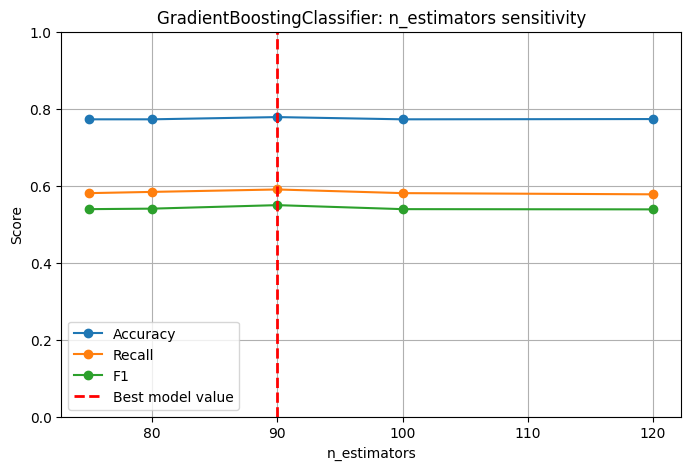

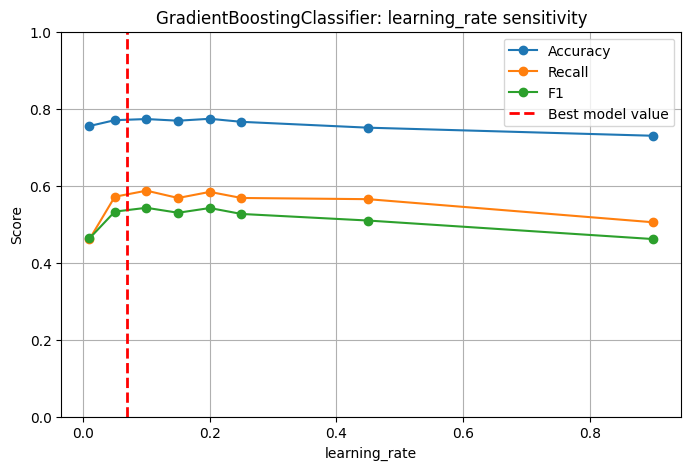

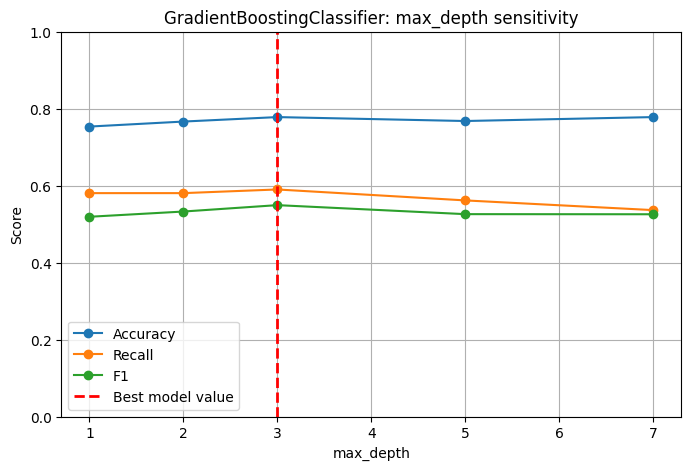

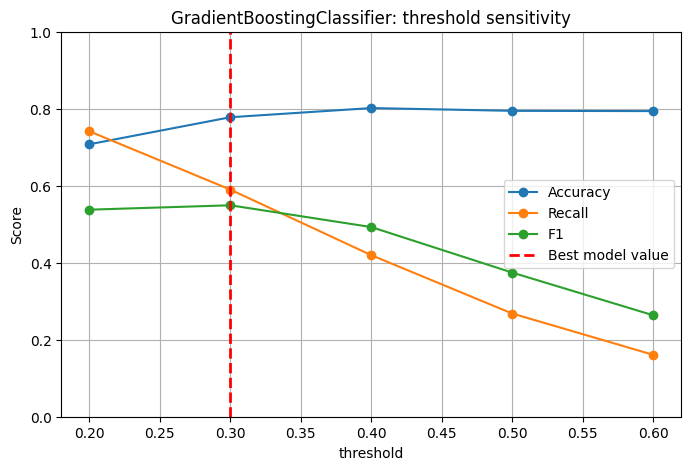

In [ ]:
# ==========================
# Imports
# ==========================

from sklearn.base import clone
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# Parameters To Test
# ==========================

PARAMETER_TESTS = {
    "n_estimators": [75, 80, 90, 100, 120],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.45, 0.9],
    "max_depth": [1, 2, 3, 5, 7],
    "threshold": [0.2, 0.3, 0.4, 0.5, 0.6]
}


# ==========================
# Select Best Model From Grid
# ==========================

best_model = grid.best_estimator_


inner_model = (
    best_model
    .named_steps["model"]
    .model
)


model_name = type(inner_model).__name__


available_parameters = inner_model.get_params()


print("Selected model:")
print(model_name)



# ==========================
# Save Best Model Parameters
# ==========================

best_model_parameters = best_model.get_params()


# ==========================
# Display Best Model Parameters
# ==========================

best_parameters_display = {}


# --------------------------
# GMM
# --------------------------

best_parameters_display["--- GMM ---"] = ""


if best_model_parameters.get("gmm") == "passthrough":

    best_parameters_display["GMM"] = "Off"

else:

    best_parameters_display["GMM"] = "On"


    if "gmm__n_components" in best_model_parameters:

        best_parameters_display["Components"] = (
            best_model_parameters["gmm__n_components"]
        )


    if "gmm__covariance_type" in best_model_parameters:

        best_parameters_display["Cov"] = (
            best_model_parameters["gmm__covariance_type"]
        )



# --------------------------
# Supervised Model
# --------------------------

best_parameters_display["--- Supervised Model ---"] = ""

best_parameters_display["Model"] = model_name



parameter_mapping = {

    "n_estimators": "Trees",

    "learning_rate": "LR",

    "max_depth": "Depth",

    "C": "C",

    "threshold": "Threshold"

}



for param, short_name in parameter_mapping.items():


    if param == "threshold":

        key = "model__threshold"

    else:

        key = f"model__model__{param}"


    if key in best_model_parameters:


        value = best_model_parameters[key]


        if isinstance(value, float):

            value = round(
                value,
                3
            )

            if value.is_integer():

                value = int(value)


        best_parameters_display[short_name] = value



best_parameters_table = pd.DataFrame(
    list(best_parameters_display.items()),
    columns=[
        "Parameter",
        "Value"
    ]
)


print(
    "\nBest Model Parameters:"
)


print(
    best_parameters_table.to_string(
        index=False
    )
)

# ==========================
# Add Logistic Regression Parameter
# ==========================

if model_name == "LogisticRegression":

    PARAMETER_TESTS.update(
        {
            "C": [
                0.001,
                0.005,
                0.01,
                0.02,
                0.03,
                0.1,
                0.2,
                0.5,
                0.7
            ]
        }
    )



# ==========================
# Evaluation Function
# ==========================

def evaluate_parameter(
    model,
    parameter_name,
    parameter_value
):

    test_model = clone(model)


    # Threshold belongs to wrapper

    if parameter_name == "threshold":

        test_model.set_params(
            model__threshold=parameter_value
        )


    # Model parameters

    else:

        test_model.set_params(
            **{
                f"model__model__{parameter_name}":
                parameter_value
            }
        )


    test_model.fit(
        X_train,
        y_train
    )


    y_pred = test_model.predict(
        X_test
    )


    return {
        parameter_name: parameter_value,

        "Accuracy": round(
            accuracy_score(
                y_test,
                y_pred
            ),
            4
        ),

        "Recall": round(
            recall_score(
                y_test,
                y_pred
            ),
            4
        ),

        "F1": round(
            f1_score(
                y_test,
                y_pred
            ),
            4
        )
    }



# ==========================
# Run Sensitivity Tests
# ==========================

for parameter_name, values in PARAMETER_TESTS.items():


    # Check if parameter belongs to model

    if (
        parameter_name != "threshold"
        and parameter_name not in available_parameters
    ):

        print(
            f"Skipping {parameter_name} "
            f"(not available for {model_name})"
        )

        continue



    # ==========================
    # Original Best Model Value
    # ==========================

    if parameter_name == "threshold":

        original_value = best_model_parameters[
            "model__threshold"
        ]

    else:

        original_value = best_model_parameters[
            f"model__model__{parameter_name}"
        ]



    results = []


    for value in values:

        results.append(
            evaluate_parameter(
                best_model,
                parameter_name,
                value
            )
        )



    results_table = pd.DataFrame(
        results
    )



    # ==========================
    # Plot
    # ==========================

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        results_table[parameter_name],
        results_table["Accuracy"],
        marker="o",
        label="Accuracy"
    )


    plt.plot(
        results_table[parameter_name],
        results_table["Recall"],
        marker="o",
        label="Recall"
    )


    plt.plot(
        results_table[parameter_name],
        results_table["F1"],
        marker="o",
        label="F1"
    )


    # Best model value marker

    plt.axvline(
        x=original_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Best model value"
    )


    plt.xlabel(
        parameter_name
    )


    plt.ylabel(
        "Score"
    )


    plt.ylim(
        0,
        1
    )


    plt.title(
        f"{model_name}: {parameter_name} sensitivity"
    )


    plt.legend()

    plt.grid()

    plt.show()

##6. Model Performance Evaluation on Test Set

This section evaluates the final CV-selected model on the independent test set using complementary classification metrics.  
The analysis includes confusion matrix, ROC-AUC, and Precision-Recall curve to assess classification performance and predictive discrimination.  

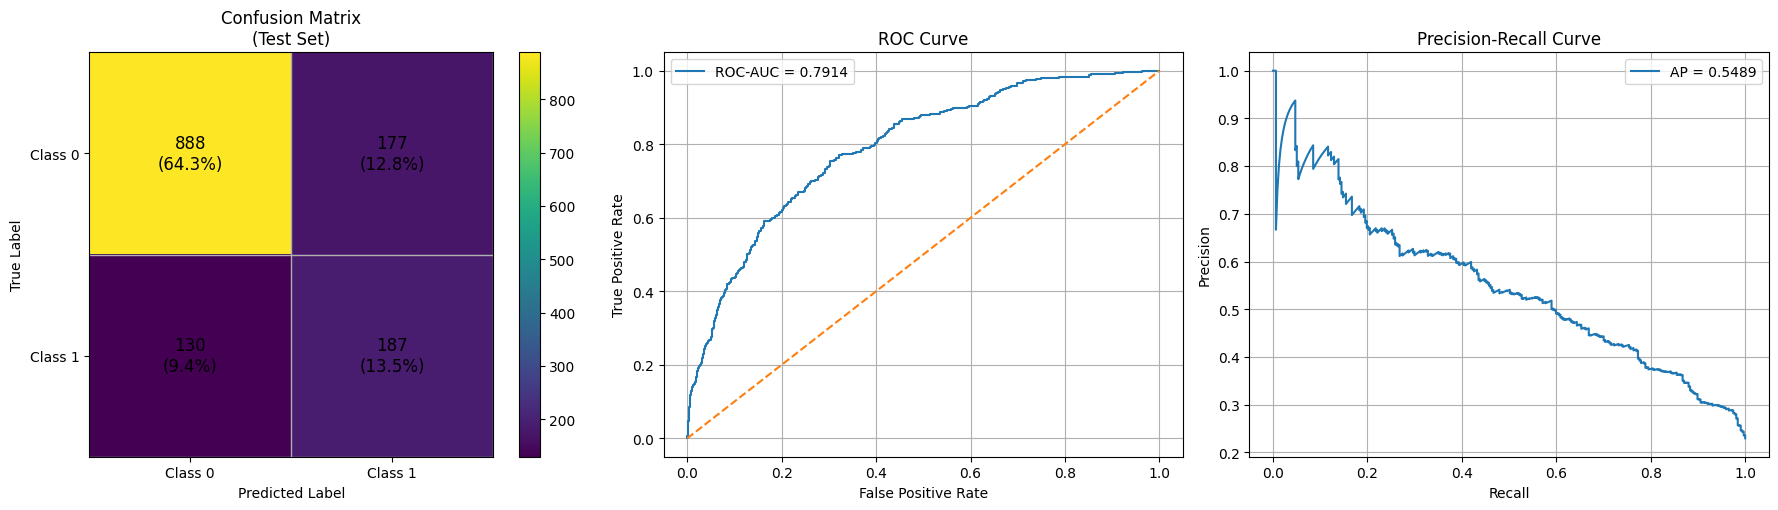


Total test samples:
1382

ROC-AUC:
0.7914

Average Precision (PR-AUC):
0.5489


In [ ]:
# ==========================
# Confusion Matrix + ROC-AUC + PR Curve
# ==========================

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt



# ==========================
# Predictions
# ==========================

y_pred = best_model.predict(
    X_test
)


y_pred_proba = best_model.predict_proba(
    X_test
)[:, 1]



# ==========================
# Metrics Calculation
# ==========================

cm = confusion_matrix(
    y_test,
    y_pred
)


fpr, tpr, _ = roc_curve(
    y_test,
    y_pred_proba
)


roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)


precision, recall, _ = precision_recall_curve(
    y_test,
    y_pred_proba
)


average_precision = average_precision_score(
    y_test,
    y_pred_proba
)



# ==========================
# Create 1x3 Subplots
# ==========================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)



# ==========================
# 1. Confusion Matrix
# ==========================

im = axes[0].imshow(
    cm,
    interpolation="nearest"
)


# Add colorbar

fig.colorbar(
    im,
    ax=axes[0]
)


axes[0].set_title(
    "Confusion Matrix\n(Test Set)"
)


axes[0].set_xlabel(
    "Predicted Label"
)


axes[0].set_ylabel(
    "True Label"
)


axes[0].set_xticks(
    [0, 1]
)


axes[0].set_yticks(
    [0, 1]
)


axes[0].set_xticklabels(
    [
        "Class 0",
        "Class 1"
    ]
)


axes[0].set_yticklabels(
    [
        "Class 0",
        "Class 1"
    ]
)



# Add values and percentages

total = cm.sum()


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        value = cm[i, j]

        percentage = (
            value / total * 100
        )

        axes[0].text(
            j,
            i,
            f"{value}\n({percentage:.1f}%)",
            ha="center",
            va="center",
            fontsize=12
        )



# Grid between cells

axes[0].set_xticks(
    [
        0.5,
        1.5
    ],
    minor=True
)


axes[0].set_yticks(
    [
        0.5,
        1.5
    ],
    minor=True
)


axes[0].grid(
    which="minor",
    linewidth=1
)


axes[0].tick_params(
    which="minor",
    bottom=False,
    left=False
)



# ==========================
# 2. ROC Curve
# ==========================

axes[1].plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)


axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


axes[1].set_xlabel(
    "False Positive Rate"
)


axes[1].set_ylabel(
    "True Positive Rate"
)


axes[1].set_title(
    "ROC Curve"
)


axes[1].legend()

axes[1].grid()



# ==========================
# 3. Precision-Recall Curve
# ==========================

axes[2].plot(
    recall,
    precision,
    label=f"AP = {average_precision:.4f}"
)


axes[2].set_xlabel(
    "Recall"
)


axes[2].set_ylabel(
    "Precision"
)


axes[2].set_title(
    "Precision-Recall Curve"
)


axes[2].legend()

axes[2].grid()



# ==========================
# Display Plots
# ==========================

plt.tight_layout()

plt.show()



# ==========================
# Print Metrics
# ==========================


print("\nTotal test samples:")
print(cm.sum())


print("\nROC-AUC:")
print(round(roc_auc, 4))


print("\nAverage Precision (PR-AUC):")
print(round(average_precision, 4))

##7. SHAP Model Interpretation

The SHAP analysis is performed on the final model configuration selected according to the highest cross-validation (CV) performance.  
Following model selection, the chosen pipeline is retrained on the complete training dataset and interpreted using SHAP values on the independent test dataset.  
The analysis quantifies the contribution and importance of individual features in the final predictive model.

SHAP shape: (1382, 44)
Number of feature names: 44

SHAP Analysis for: GradientBoostingClassifier

Top SHAP Features:
          Feature  Mean_SHAP
     HashkaotBank   0.548620
              Gil   0.271120
      ShokelKniot   0.216334
  HeshbonotBazman   0.213161
  HashkaotShukHon   0.183042
work_income_level   0.172589
      MispYeladim   0.146525
         LoHosech   0.130994
   health_problem   0.126055
      YedaHashkaa   0.120485


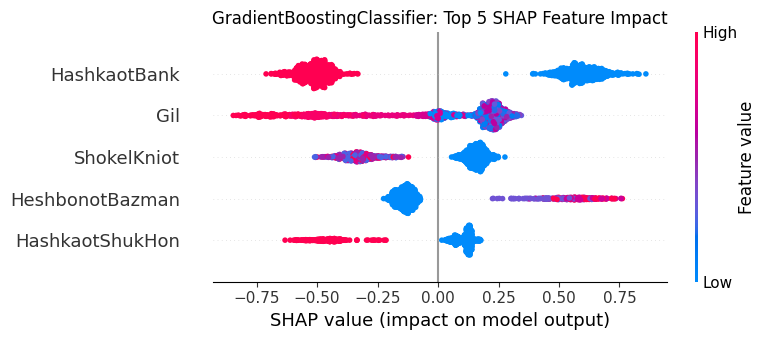

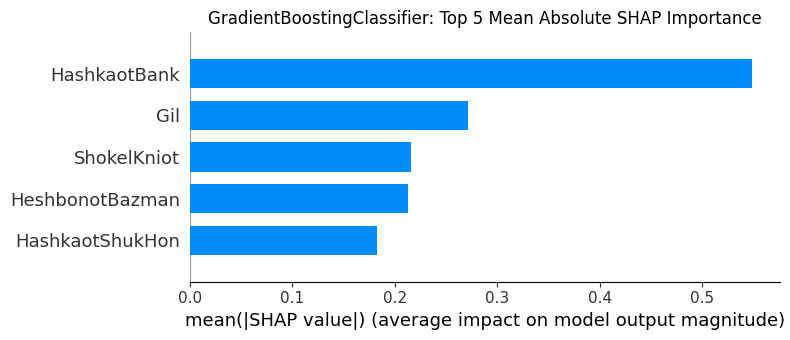

In [ ]:
# ==========================
# SHAP Analysis - Full Model Features
# ==========================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# ==========================
# Extract Final Model
# ==========================

best_model = grid.best_estimator_


final_classifier = (
    best_model
    .named_steps["model"]
    .model
)


model_name = type(final_classifier).__name__



# ==========================
# Transform Test Data Through Pipeline
# (Imputer + Scaler + GMM)
# ==========================

X_test_transformed = (
    best_model
    .named_steps["gmm"]
)


# Apply preprocessing before classifier

X_test_shap = best_model[:-1].transform(
    X_test
)



# ==========================
# Feature Names
# ==========================

# Original dataset features

original_features = [
    'YelidBrham', 'female', 'Gil', 'ShnatAliya', 'MatzavMishp',
    'MispYeladim', 'Dat', 'SherutTzahal', 'SherutLeumi',
    'RishyonNehiga', 'SugMeshekBait_C', 'Earners',
    'health_problem', 'ShnotLimud', 'hebrew_proficiency',
    'MaamadAvoda_C_wp', 'HekefMisra_C_wp',
    'MerutzeAvoda_wp', 'work_income_level',
    'HitnadvutShana', 'TrumaShana', 'AchrayutKesef',
    'MenahelTazrim', 'MishtameshAppMaakav',
    'HoraotKeva', 'HashkaotBank', 'HassachMezuman',
    'HassachGmach', 'HashkaotShukHon',
    'HashkaotMatbeotVirt', 'HashkaotAher',
    'YedaHashkaa', 'SikunHashkaot',
    'LoHosech', 'HeshbonotBazman',
    'MatarotKaspiot', 'ShokelKniot'
]


# Get transformed feature names from preprocessing

try:

    processed_features = (
        best_model[:-2]
        .get_feature_names_out()
        .tolist()
    )

except:

    processed_features = original_features



# Add GMM features

if (
    best_model.named_steps["gmm"] != "passthrough"
):

    n_gmm_features = (
        best_model
        .named_steps["gmm"]
        .n_components
    )

    gmm_features = [
        f"GMM_{i}"
        for i in range(n_gmm_features)
    ]

else:

    gmm_features = []



feature_names = (
    processed_features
    +
    gmm_features
)


print(
    "SHAP shape:",
    X_test_shap.shape
)

print(
    "Number of feature names:",
    len(feature_names)
)


# Convert to DataFrame

X_test_shap = pd.DataFrame(
    X_test_shap,
    columns=feature_names
)



# ==========================
# SHAP Explainer
# ==========================

explainer = shap.TreeExplainer(
    final_classifier
)


shap_values = explainer.shap_values(
    X_test_shap
)



# Handle binary classification format

if isinstance(
    shap_values,
    list
):

    shap_values = shap_values[1]



# ==========================
# SHAP Importance Table
# ==========================

shap_importance = pd.DataFrame(
    {
        "Feature": feature_names,

        "Mean_SHAP":
        np.abs(shap_values)
        .mean(axis=0)
    }
)


shap_importance = (
    shap_importance
    .sort_values(
        by="Mean_SHAP",
        ascending=False
    )
)



print(
    f"\nSHAP Analysis for: {model_name}"
)


print(
    "\nTop SHAP Features:"
)


print(
    shap_importance
    .head(10)
    .to_string(
        index=False
    )
)



# ==========================
# Select Top 5 Features
# ==========================

top_features = (
    shap_importance
    .head(5)
    ["Feature"]
    .tolist()
)


top_indices = [
    feature_names.index(feature)
    for feature in top_features
]


shap_values_top5 = (
    shap_values[
        :,
        top_indices
    ]
)


X_test_top5 = X_test_shap[
    top_features
]



# ==========================
# SHAP Beeswarm Plot
# ==========================

plt.figure(
    figsize=(10, 6)
)


shap.summary_plot(
    shap_values_top5,
    X_test_top5,
    max_display=5,
    show=False
)


plt.title(
    f"{model_name}: Top 5 SHAP Feature Impact"
)


plt.tight_layout()

plt.show()



# ==========================
# SHAP Bar Plot
# ==========================

plt.figure(
    figsize=(10, 6)
)


shap.summary_plot(
    shap_values_top5,
    X_test_top5,
    plot_type="bar",
    max_display=5,
    show=False
)


plt.title(
    f"{model_name}: Top 5 Mean Absolute SHAP Importance"
)


plt.tight_layout()

plt.show()

In [ ]:
print(saved_figures.keys())

In [ ]:
# ==========================
# Display Saved Figures Safely
# As Images
# ==========================

from IPython.display import display, Image
import io


print(
    "Saved figures:",
    len(saved_figures)
)


for name, fig in saved_figures.items():

    if len(fig.axes) == 0:
        continue


    print(name)


    # Save figure to memory buffer
    # without changing original figure

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=150,
        bbox_inches="tight"
    )

    buffer.seek(0)


    # Display image with variable name

    display(
        Image(
            data=buffer.read(),
            width=350
        )
    )